<a href="https://colab.research.google.com/github/Arlan999qi/AI-Univariate-Linear-Regression/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
# y_train should not be scaled as it contains labels.
# x_test = x_test / 255.0 # Also scale x_test for consistency if you plan to use it later.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


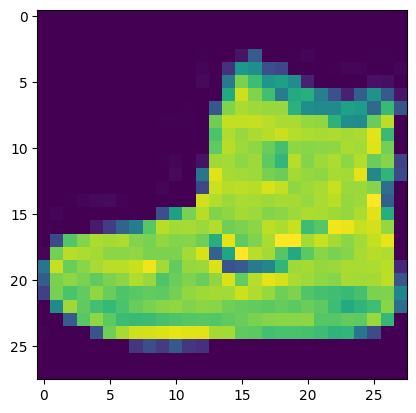

In [ ]:
plt.imshow(x_train[0])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(units=128, activation='relu'),
    Dense(units=10, activation='softmax')
])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer = 'adam',
              metrics = ['accuracy']
              )

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7832 - loss: 0.6262 - val_accuracy: 0.8503 - val_loss: 0.4313
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8629 - loss: 0.3815 - val_accuracy: 0.8545 - val_loss: 0.3918
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8758 - loss: 0.3369 - val_accuracy: 0.8697 - val_loss: 0.3653
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8880 - loss: 0.3099 - val_accuracy: 0.8684 - val_loss: 0.3587
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8937 - loss: 0.2887 - val_accuracy: 0.8747 - val_loss: 0.3485
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8947 - loss: 0.2798 - val_accuracy: 0.8737 - val_loss: 0.3561
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8992 - loss: 0.2668 - val_accuracy: 0.8826 - val_loss: 0.3386
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9052 - loss: 0.2540 

In [ ]:
import numpy as np
img = x_test[657]
img_batch = np.expand_dims(img, axis=0)
prediction = model.predict(img_batch)
result = np.argmax(prediction)
print(f"The model predicts class {result}, Actual class is {y_test[657]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
The model predicts class 4, Actual class is 4


In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


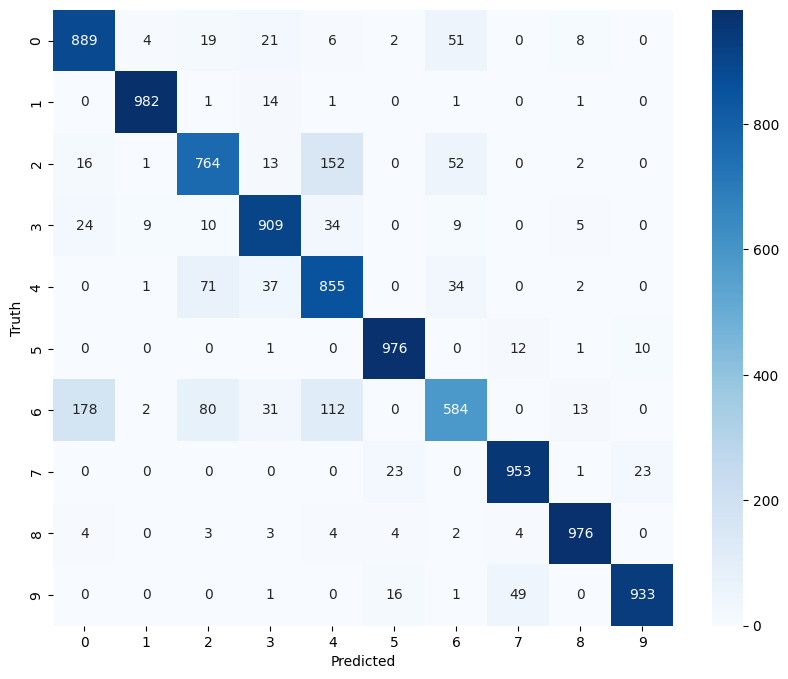

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

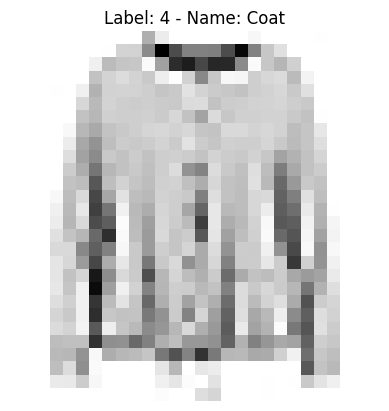

In [ ]:
import matplotlib.pyplot as plt

# Choose an index to check
i = 25

plt.figure()
plt.imshow(x_test[i], cmap=plt.cm.binary) # cmap='binary' makes it look like the labs
plt.title(f"Label: {y_test[i]} - Name: {class_names[y_test[i]]}")
plt.axis('off') # Hides the x and y axis numbers
plt.show()

Actually a Pullover
Model thought it was a Shirt


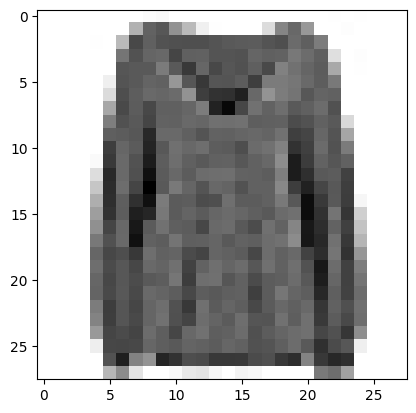

In [ ]:
# Find where the model's guess was NOT the actual answer
incorrect_indices = np.where(y_pred != y_test)[0]

# Pick one of the mistakes
wrong_i = incorrect_indices[6]

print(f"Actually a {class_names[y_test[wrong_i]]}")
print(f"Model thought it was a {class_names[y_pred[wrong_i]]}")
plt.imshow(x_test[wrong_i], cmap='binary')